<a href="https://colab.research.google.com/github/AbelAtares/Neural-Network-Digit-Recognition-MNIST/blob/main/Neural_Network_Digit_Recognition_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **NEURAL NETWORK - DIGIT RECOGNITION**

This notebook implements a **neural network for digit recognition** built entirely from scratch using **NumPy**, without any deep learning frameworks like TensorFlow or PyTorch.  

The model is trained and tested on the **MNIST dataset**, which contains 42,000 grayscale images of handwritten digits (0–9).  

## **Import and study data**

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

As we can see from the shape of the dataframe, it contains **42,000 images**, each representing a digit from 0 to 9. Each image has **784 pixels**, with values ranging from **0 (black)** to **255 (white)**. And the column label is the target variable.

## **Data split**

First, we will shuffle the dataset to ensure the data is randomly distributed before splitting it into **training** and **development** sets.

In [5]:
df = np.array(df)
m, n = df.shape
np.random.shuffle(df)

We take the first 1,000 records from the shuffled dataset as the **development set**, and the remaining 41,000 as the **training set**.  

**Note:** In both cases, the first row of the transposed dataframe corresponds to the labels.  
Additionally, we normalize all pixel values by dividing by 255, so that all values range between 0 and 1.

In [6]:
df_dev = df[0:1000].T
Y_dev = df_dev[0]
X_dev = df_dev[1:n]
X_dev = X_dev / 255.
m_dev = X_dev.shape

df_train = df[1000:m].T
Y_train = df_train[0]
X_train = df_train[1:n]
X_train = X_train / 255.
m_train = X_train.shape

In [7]:
X_train, Y_train, m_train

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([6, 2, 5, ..., 3, 7, 3]),
 (784, 41000))

In [8]:
X_dev, Y_dev, m_dev

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([2, 7, 2, 4, 2, 3, 3, 5, 0, 5, 1, 9, 8, 6, 2, 0, 2, 8, 8, 9, 9, 8,
        7, 1, 6, 3, 9, 5, 0, 4, 8, 0, 9, 0, 8, 4, 6, 5, 5, 8, 1, 9, 1, 4,
        0, 8, 4, 1, 0, 6, 3, 9, 9, 6, 1, 7, 7, 2, 3, 2, 4, 8, 0, 8, 4, 3,
        1, 3, 1, 0, 5, 0, 1, 4, 2, 1, 9, 9, 9, 4, 7, 7, 8, 9, 3, 5, 2, 1,
        6, 8, 1, 9, 3, 0, 8, 0, 6, 3, 9, 0, 2, 6, 9, 6, 2, 3, 2, 0, 4, 7,
        5, 2, 5, 3, 7, 7, 9, 4, 0, 4, 5, 9, 3, 5, 4, 9, 3, 0, 2, 1, 3, 6,
        4, 1, 5, 9, 8, 5, 3, 7, 3, 6, 7, 3, 4, 7, 6, 4, 2, 1, 3, 4, 2, 8,
        2, 8, 2, 1, 2, 8, 3, 2, 2, 8, 8, 5, 0, 8, 8, 3, 4, 0, 8, 6, 6, 7,
        6, 7, 1, 6, 2, 6, 5, 3, 7, 7, 5, 2, 8, 8, 3, 1, 5, 0, 0, 1, 9, 3,
        6, 4, 1, 4, 7, 3, 1, 3, 3, 7, 1, 3, 3, 1, 4, 3, 0, 7, 7, 5, 8, 9,
        1, 

## **Model implementation**

As illustrated in the diagram below, we will use a **small neural network** consisting of:  
- An **input layer** with 784 units (one for each pixel)  
- A **hidden layer** with 10 units, using the **ReLU activation function**  
- An **output layer** with 10 units, using the **softmax activation function** to predict digit probabilities (0–9)

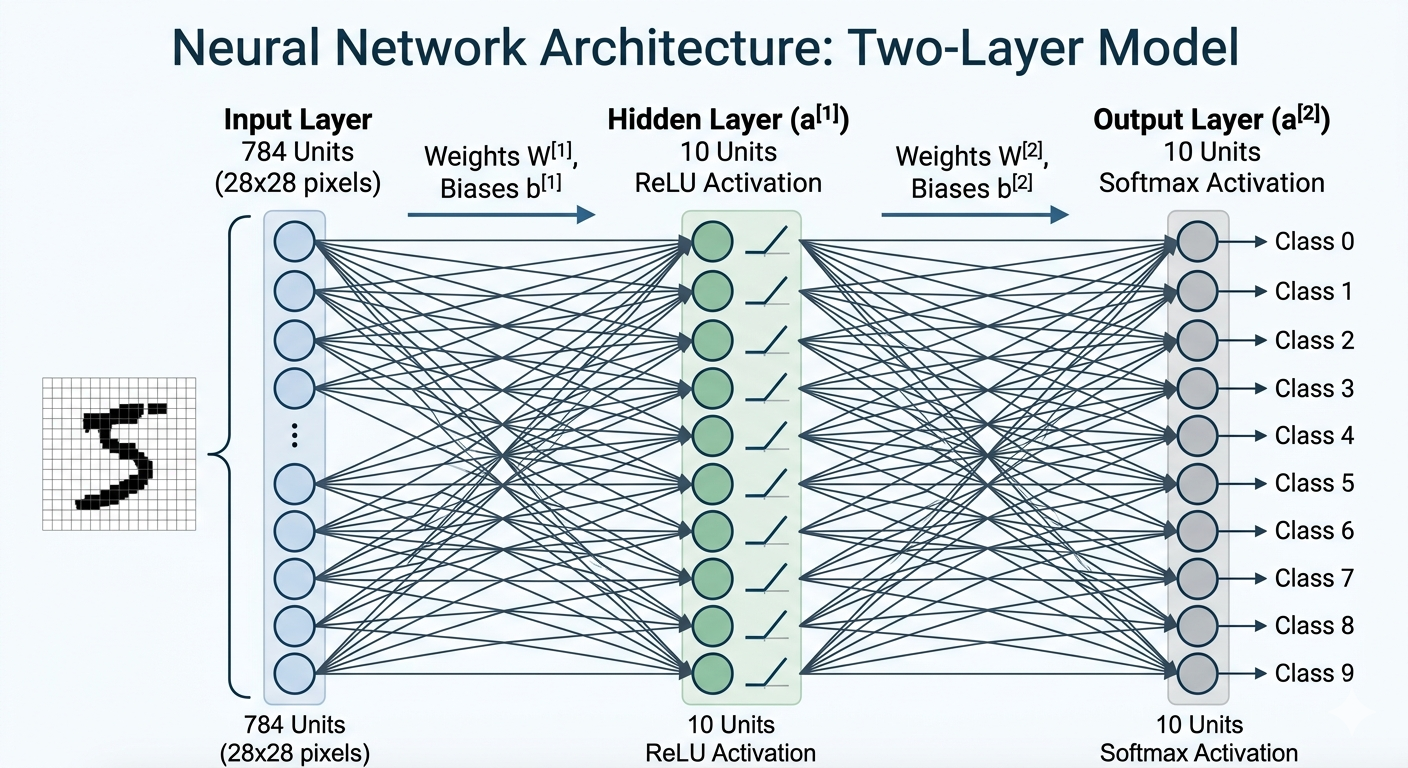

Now, let's dive into the mathematics. First, we will **randomly initialize the weights and biases** to start the training process.

In [9]:
def init_params():
    W1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    W2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return W1, b1, W2, b2

We define **ReLU** and **softmax** functions as follows:

In [10]:
def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A

Next, we define the **forward and backward propagation** processes used to train the neural network.

In [11]:
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

Finally, we **update the weights and biases** using the gradients computed during backpropagation, as follows:

In [12]:
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

To complete the model development, we define the prediction function, the accuracy metric and the gradient descent optimization process.

In [18]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))
    return W1, b1, W2, b2

## **Model training**

Now, let’s move on to the exciting part, training the model on our data and see how well it performs:

In [19]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.15, 600)

Iteration:  0
[2 2 5 ... 5 5 5] [6 2 5 ... 3 7 3]
0.09709756097560976
Iteration:  50
[2 2 8 ... 9 7 3] [6 2 5 ... 3 7 3]
0.6598536585365854
Iteration:  100
[8 2 8 ... 5 7 3] [6 2 5 ... 3 7 3]
0.7658536585365854
Iteration:  150
[6 2 8 ... 5 7 3] [6 2 5 ... 3 7 3]
0.8070975609756098
Iteration:  200
[6 2 8 ... 5 7 3] [6 2 5 ... 3 7 3]
0.8300731707317073
Iteration:  250
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.845609756097561
Iteration:  300
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8558536585365853
Iteration:  350
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8638780487804878
Iteration:  400
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8691951219512195
Iteration:  450
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8739024390243902
Iteration:  500
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8776341463414634
Iteration:  550
[6 2 8 ... 3 7 3] [6 2 5 ... 3 7 3]
0.8809268292682927


During training, we can observe that the model’s accuracy steadily improves over iterations. Starting from an **initial accuracy of ~9.7%** (which is expected since the weights and biases were randomly initialized and there are 10 possible output classes), it gradually increases as gradient descent updates the weights and biases, **reaching ~88% after 600 iterations**. This demonstrates that the network is learning from the data and converging towards better predictions.

## **Model testing**

To evaluate the model, we define the **test_prediction** function to compare the network’s prediction with the actual label for a given image.

In [22]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)

    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [6]
Label:  6


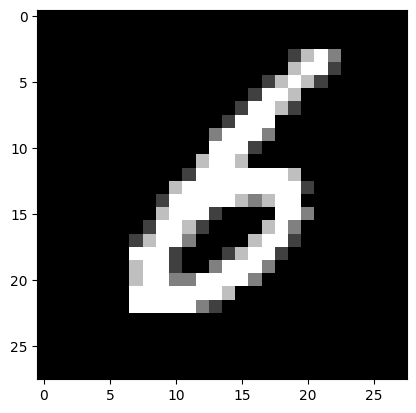

Prediction:  [2]
Label:  2


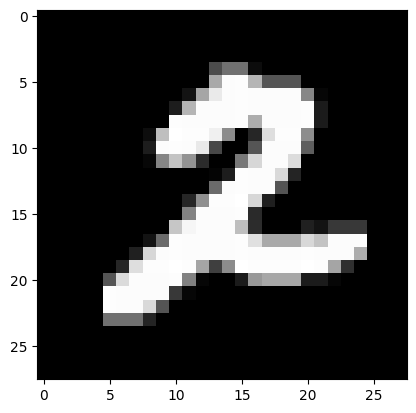

Prediction:  [8]
Label:  5


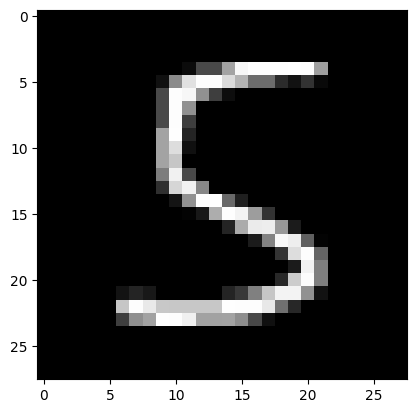

Prediction:  [9]
Label:  7


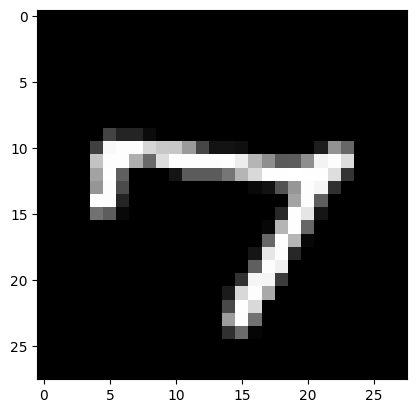

Prediction:  [3]
Label:  3


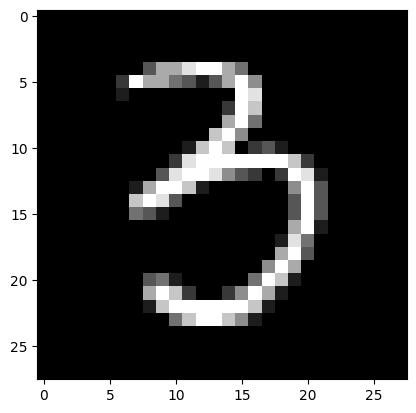

Prediction:  [2]
Label:  2


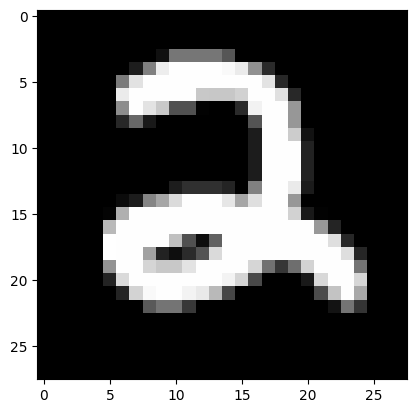

Prediction:  [3]
Label:  3


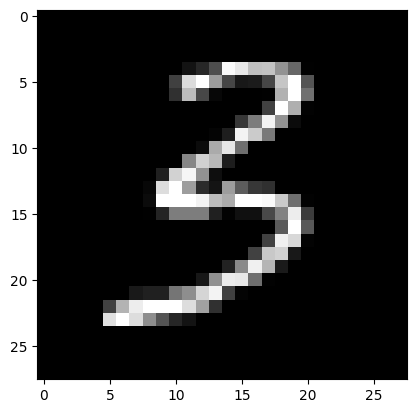

Prediction:  [8]
Label:  8


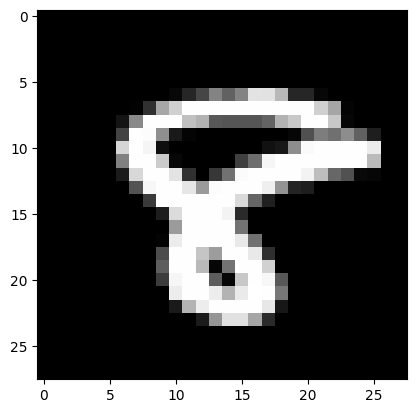

Prediction:  [9]
Label:  9


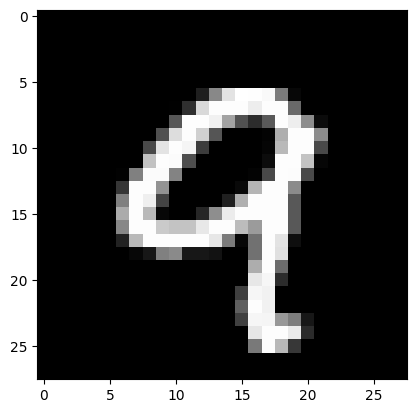

Prediction:  [8]
Label:  8


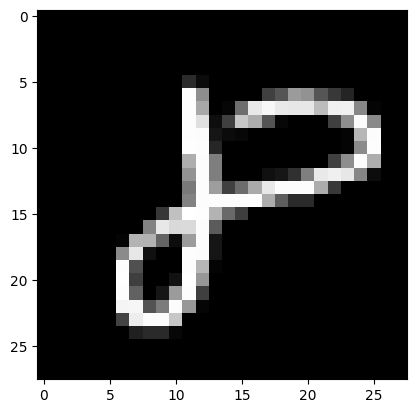

Prediction:  [8]
Label:  8


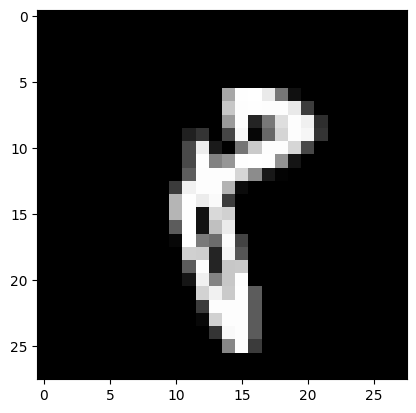

Prediction:  [5]
Label:  5


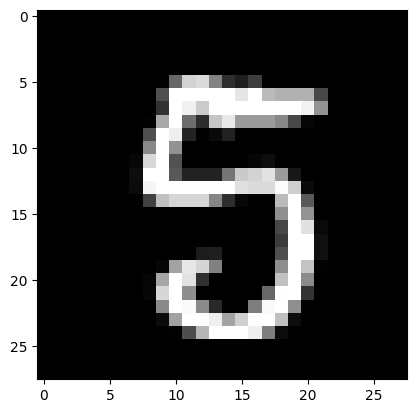

Prediction:  [0]
Label:  0


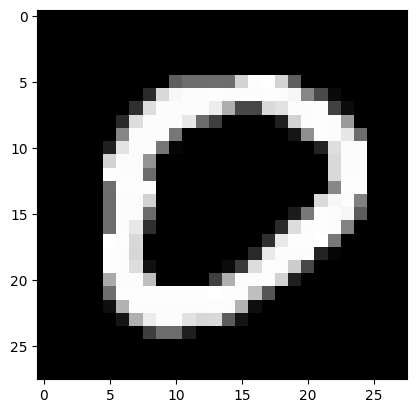

Prediction:  [0]
Label:  0


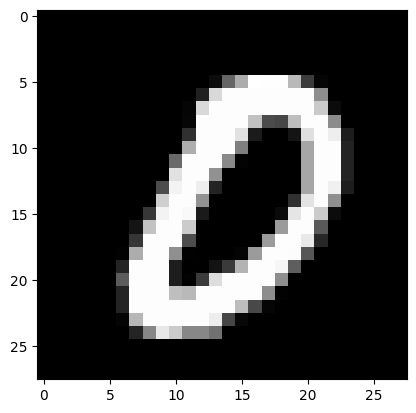

Prediction:  [5]
Label:  5


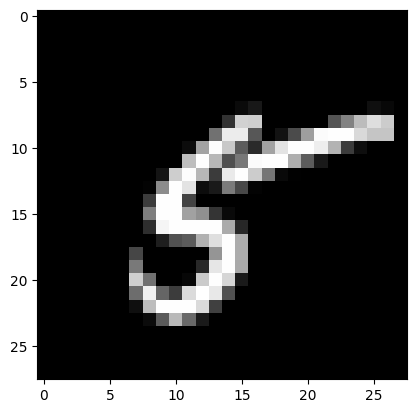

In [23]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)
test_prediction(4, W1, b1, W2, b2)
test_prediction(5, W1, b1, W2, b2)
test_prediction(6, W1, b1, W2, b2)
test_prediction(7, W1, b1, W2, b2)
test_prediction(8, W1, b1, W2, b2)
test_prediction(9, W1, b1, W2, b2)
test_prediction(10, W1, b1, W2, b2)
test_prediction(11, W1, b1, W2, b2)
test_prediction(12, W1, b1, W2, b2)
test_prediction(13, W1, b1, W2, b2)
test_prediction(14, W1, b1, W2, b2)

In [17]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[2 4 3 4 3 3 5 5 0 5 1 9 8 6 2 0 3 8 8 4 9 8 7 1 6 3 7 5 0 4 8 0 9 0 1 4 6
 5 5 8 1 9 1 4 0 5 4 1 0 6 3 9 7 6 1 7 7 2 3 2 4 3 0 8 4 3 1 3 1 0 5 0 1 4
 2 1 4 7 3 4 7 7 8 9 7 5 2 1 6 3 1 9 3 0 8 0 6 3 9 0 2 6 9 6 2 5 2 0 4 9 5
 2 5 3 9 7 9 9 2 4 5 9 3 5 4 9 3 0 2 1 3 6 4 1 5 9 8 5 3 7 3 6 7 3 4 7 6 4
 2 1 7 4 2 8 2 8 2 1 2 6 3 2 2 9 8 5 0 8 9 5 4 0 5 6 6 7 6 7 1 6 2 6 5 3 7
 7 5 2 8 8 3 1 5 0 2 1 9 2 6 4 1 4 7 3 1 3 3 7 1 3 0 1 9 5 0 1 7 5 3 9 1 9
 9 7 8 1 6 0 9 6 4 1 9 8 4 5 7 2 7 7 5 6 6 3 0 7 1 3 8 8 1 5 3 4 8 5 3 2 6
 8 0 0 4 4 7 9 9 6 9 8 3 2 5 9 7 5 7 4 7 2 3 0 0 4 6 1 1 6 2 0 9 8 5 1 7 4
 2 8 0 5 8 5 2 9 3 8 3 2 4 2 2 5 3 9 6 8 8 8 7 2 2 9 0 1 3 0 3 9 0 3 1 2 1
 4 1 6 5 7 9 7 4 8 9 6 6 2 2 2 2 6 2 2 9 3 8 4 5 2 6 3 0 7 8 6 9 9 6 8 0 2
 7 4 0 3 6 0 8 8 2 3 8 6 5 0 6 2 8 0 3 7 2 3 0 7 4 3 0 3 4 0 6 9 1 8 1 8 7
 3 1 6 5 4 5 9 0 6 1 2 3 2 1 7 9 5 4 8 2 7 9 6 0 9 1 3 7 3 4 4 4 7 3 8 4 4
 5 7 3 9 4 0 2 7 3 1 2 6 9 0 3 6 6 2 3 0 1 7 8 1 1 5 1 4 9 4 6 7 8 2 1 9 0
 9 9 6 2 6 6 3 8 6 7 3 6 

np.float64(0.874)

Overall, the model performs quite well, achieving **~87% accuracy** on the training data. As we observed in the testing examples above, the predictions are reasonably accurate, even with a relatively small neural network. This demonstrates that, with a modest network architecture and sufficient training data, we can achieve meaningful results in digit recognition.  

I hope you enjoyed exploring this project and found some useful insights to take away for your own experiments.